In [7]:
import matplotlib.pyplot as plt
from pathlib import Path
import torch

checkpoint_folder = Path("./../training/checkpoints")

epochs = []
losses = []

for checkpoint_file in sorted(checkpoint_folder.glob("epoch_*.pt"),key=lambda x: int(x.stem.split("_")[1])):
    checkpoint = torch.load(checkpoint_file,map_location="cpu")
    epochs.append(checkpoint["epoch"] + 1)
    losses.append(checkpoint["loss"])


print (epochs)
print (losses)


[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
[5.955246346760298, 5.785867790236674, 5.734618278574242, 5.190962592702946, 3.7117478669909687, 3.3778097696478184, 3.21106357444334, 3.0689476944032017, 2.960910519075239, 2.889301249490543]


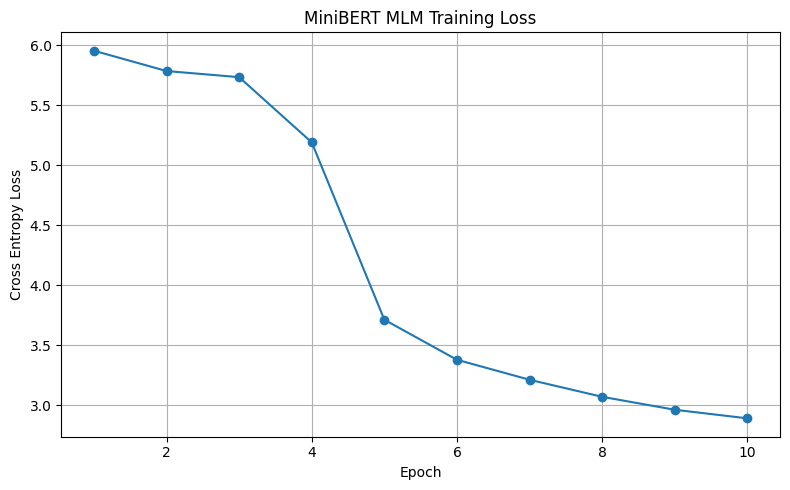

In [9]:
plt.figure(figsize=(8,5))
plt.plot(epochs, losses, marker='o')
plt.title("MiniBERT MLM Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross Entropy Loss")
plt.grid(True)
plt.tight_layout()
plt.savefig("training_loss_curve.png",dpi=300,bbox_inches="tight")
plt.show()

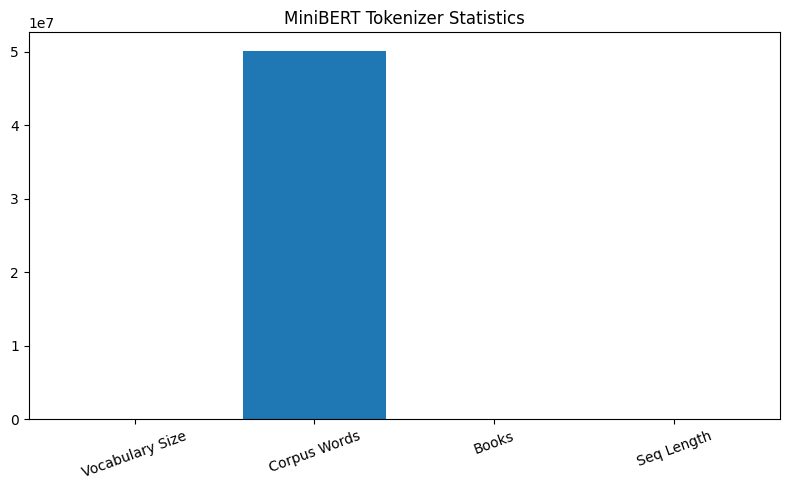

In [ ]:
stats = {
    "Vocabulary Size":8000,
    "Corpus Words":50122524,
    "Books":606,
    "Seq Length":128
}
plt.figure(figsize=(8,5))
plt.bar(stats.keys(),stats.values())
plt.title("MiniBERT Tokenizer Statistics")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(
    "tokenizer_stats.png",
    dpi=300
)

plt.show()

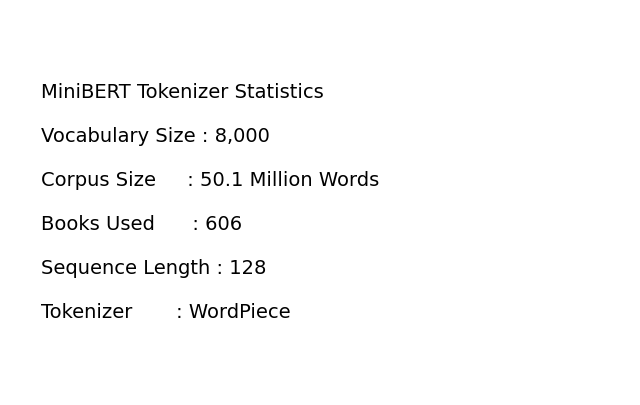

In [ ]:
fig, ax = plt.subplots(figsize=(8,5))
ax.axis("off")
text = f"""
MiniBERT Tokenizer Statistics

Vocabulary Size : 8,000

Corpus Size     : 50.1 Million Words

Books Used      : 606

Sequence Length : 128

Tokenizer       : WordPiece
"""

ax.text(
    0.05,
    0.5,
    text,
    fontsize=14,
    va="center"
)

plt.savefig(
    "tokenizer_stats.png",
    dpi=300,
    bbox_inches="tight"
)

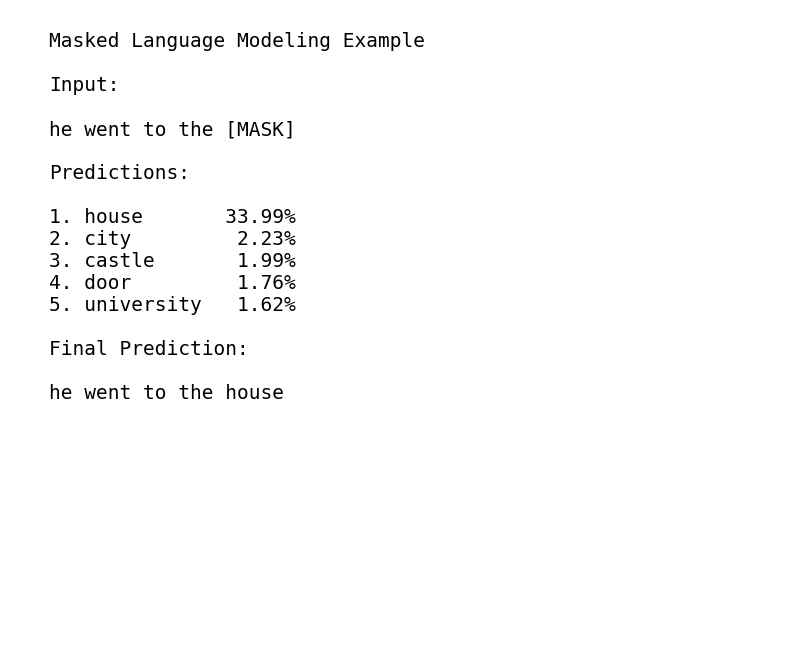

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(
    figsize=(10,6)
)

ax.axis("off")

text = """
Masked Language Modeling Example

Input:

he went to the [MASK]

Predictions:

1. house       33.99%
2. city         2.23%
3. castle       1.99%
4. door         1.76%
5. university   1.62%

Final Prediction:

he went to the house
"""

ax.text(
    0.05,
    0.5,
    text,
    fontsize=14,
    family="monospace"
)

plt.savefig(
    "mlm_prediction_example.png",
    dpi=300,
    bbox_inches="tight"
)

Input Tokens
      ↓
Token Embeddings
      +
Position Embeddings
      ↓
Transformer Encoder Block × 6
      ↓
Contextual Representations
      ↓
MLM Head (Linear Layer)
      ↓
Vocabulary Logits (8000)
      ↓
Masked Token Prediction

d_model = 256
Heads = 8
Layers = 6
Seq Length = 128
Vocabulary = 8000

Project Gutenberg Books
(44,240 Books)
          ↓

Corpus Creation
(50 Million Words)
          ↓

WordPiece Tokenizer
(Vocab = 8,000)
          ↓

Token IDs
(token_ids.pt)
          ↓

MLM Dataset
(15% Masking)
          ↓

MiniBERT
(6 Encoder Layers)
          ↓

MLM Head
          ↓

Cross Entropy Loss
          ↓

Checkpoint Saving
(best_model.pt)

In [ ]:
import os
import sys
from pathlib import Path

project_root = Path("./..")
sys.path.insert(0, str(project_root))

import torch
import matplotlib.pyplot as plt
from models.bert_for_mlm import BERTForMLM
from tokenizers import Tokenizer

device= torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# texts = [
#     "the king and the queen walked together",
#     "he went to the house",
#     "it was a good day",
#     "the dog chased the cat",
#     "the sun rose in the east"
# ]

texts = [
    "the king and the queen walked together",
]

tokenIDs_saveFile='./../training/temp_tokenIDs.pt'
tokenizerJSON_file='./../tokenizer/artifacts/tokenizer.json'
modelChekpoint_file='./../training/checkpoints/best_model.pt'

tokenizer= Tokenizer.from_file(tokenizerJSON_file)
vocabSize = tokenizer.get_vocab_size()
model = BERTForMLM(vocabSize=vocabSize)
checkpoint = torch.load(modelChekpoint_file)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)

tokens=[]
att_matrices=[]
for text in texts:
    encoding = tokenizer.encode(text)
    tokens.append(encoding.tokens)
    inputIDs = torch.tensor([encoding.ids],dtype=torch.long).to(device)

    with torch.no_grad():
        logits, temp_att_matrices = model(inputIDs)
    
    att_matrices.append(temp_att_matrices)

NameError: name '__file__' is not defined

In [2]:
plots = [
    (0, 0, 0),  # Sentence 1, Layer 1 Head 1
    (0, 1, 3),  # Sentence 1, Layer 2 Head 4
    (0, 2, 0),  # Sentence 1, Layer 3 Head 1
    (0, 5, 0),  # Sentence 1, Layer 6 Head 1
]

fig, axes = plt.subplots(2, 2, figsize=(8, 8))
axes = axes.flatten()
for ax, (batchItem, layer, head) in zip(axes, plots):
    im = ax.imshow(att_matrices[batchItem][0, layer, head].cpu().numpy())
    ax.set_title(f"Layer {layer+1}, Head {head+1}")
    ax.set_xlabel("Key Token")
    ax.set_ylabel("Query Token")
    fig.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.subplots_adjust(hspace=0.35)
plt.savefig(f"./notebooks/attention_heatmaps", dpi=300)
plt.show()

NameError: name 'plt' is not defined